# 01 — Exploration des données

**Projet YPerf — Analyse des performances olympiques pour les JO 2028**

Objectif : prendre connaissance du jeu de données brut, mesurer sa **quantité** et sa **qualité** (valeurs manquantes, doublons, couverture) avant tout traitement.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Racine projet :', ROOT)

Racine projet : C:\Users\nicol\ynov\Fil Rouge\Projet-Fil-Rouge-J.O


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')
from src.data.data_loader import load_raw_data
from src.analysis.statistics import data_quality_report

df = load_raw_data()
print(f'Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head()

Dimensions : 252,565 lignes x 11 colonnes


,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


## Structure et types

In [3]:
df.dtypes

player_id     int64
Name         object
Sex          object
Team         object
NOC          object
Year          int64
Season       object
City         object
Sport        object
Event        object
Medal        object
dtype: object

## Audit qualité des données

On vérifie les valeurs manquantes, le nombre de modalités et les doublons.

In [4]:
data_quality_report(df)

,dtype,n_missing,pct_missing,n_unique
player_id,int64,0,0.0,235903
Name,object,0,0.0,129992
Sex,object,0,0.0,2
Team,object,0,0.0,1193
NOC,object,0,0.0,234
Year,int64,0,0.0,31
Season,object,0,0.0,1
City,object,0,0.0,23
Sport,object,0,0.0,76
Event,object,0,0.0,1041


In [5]:
print('Doublons exacts :', df.duplicated().sum())
print('Valeurs manquantes totales :', int(df.isna().sum().sum()))

Doublons exacts : 0
Valeurs manquantes totales : 0


## Couverture temporelle

Le dataset ne contient que les **JO d'été**, de 1896 à 2024.

In [6]:
print('Saisons :', df['Season'].unique())
print('Années :', df['Year'].min(), '->', df['Year'].max())
print("Nombre d'éditions :", df['Year'].nunique())

Saisons : ['Summer']
Années : 1896 -> 2024
Nombre d'éditions : 31


## Distribution des médailles

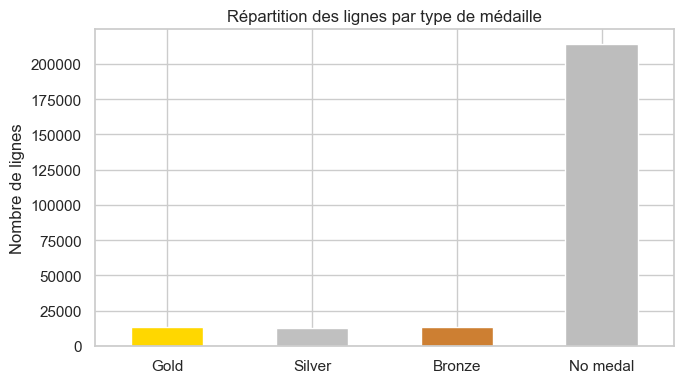

In [7]:
order = ['Gold', 'Silver', 'Bronze', 'No medal']
counts = df['Medal'].value_counts().reindex([m for m in order if m in df['Medal'].unique()])
fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind='bar', color=['#FFD700', '#C0C0C0', '#CD7F32', '#BDBDBD'], ax=ax)
ax.set_title('Répartition des lignes par type de médaille')
ax.set_ylabel('Nombre de lignes'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Top 10 des sports les plus représentés

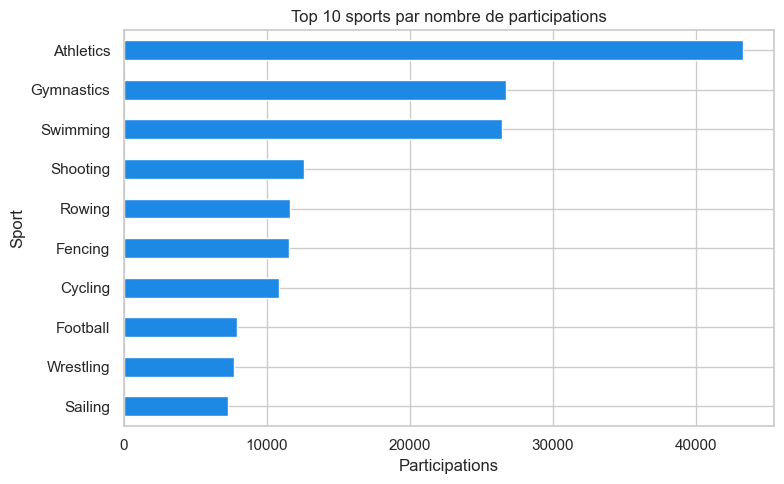

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
df['Sport'].value_counts().head(10).sort_values().plot(kind='barh', color='#1E88E5', ax=ax)
ax.set_title('Top 10 sports par nombre de participations'); ax.set_xlabel('Participations')
plt.tight_layout(); plt.show()

## Évolution de la participation

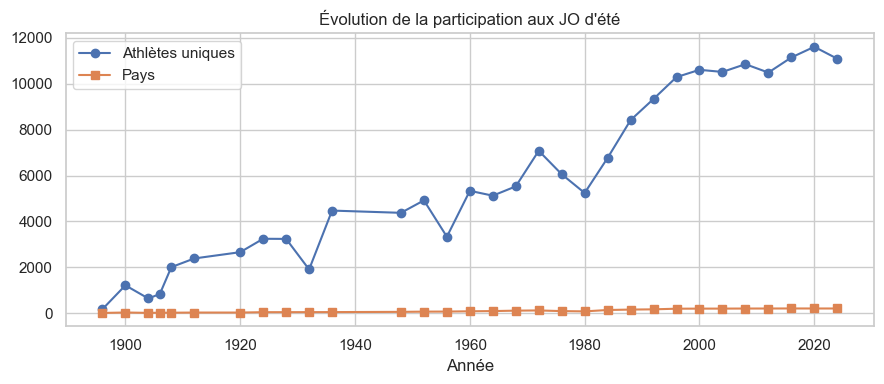

In [9]:
part = df.groupby('Year').agg(Athletes=('Name', 'nunique'), Pays=('NOC', 'nunique')).reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(part['Year'], part['Athletes'], marker='o', label='Athlètes uniques')
ax.plot(part['Year'], part['Pays'], marker='s', label='Pays')
ax.set_title("Évolution de la participation aux JO d'été")
ax.set_xlabel('Année'); ax.legend(); plt.tight_layout(); plt.show()

## Conclusion

- Jeu de données volumineux (~252 000 participations) couvrant **1896–2024**, JO d'été uniquement.
- **Aucune valeur manquante** : les non-médaillés sont notés `No medal` (et non `NaN`).
- Présence de **doublons** et de **NOC historiques** (URSS, RDA…) à traiter → notebook `02`.
- La participation et la diversité des pays croissent fortement au fil des éditions.